# Exploring Clusters

This notebook explores the clusters that were formed by the K-Means Clustering in the notebook `module_1_clustering.ipynb`. Specifically, the goal is to determine the structure of the clusters across the real-estate, social and commercial dimension. 

## Load packages and Data

In [66]:
#load packages
import pandas as pd 
import numpy as np
from sklearn.impute import KNNImputer
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

In [43]:
#load dataframes 
clusters = pd.read_csv("../../data/Module_1/cluster_assignments.csv", dtype={"plr_id": str})
features = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
ms = pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})

#define id columns and feature columns
id_cols = ["plr_id", "plr_name", "bez"]
feat_cols = [c for c in features.columns if c not in id_cols]

#impute missing values: 
X = features[feat_cols].copy()

# impute feature columns
X_imp = pd.DataFrame(
    KNNImputer(n_neighbors=3).fit_transform(X),
    columns=feat_cols, index=features.index,
)

#concat dataframe
df_imp = pd.concat([features[id_cols], X_imp], axis=1)

print(df_imp.shape, "| remaining NaN in feature columns:",
      int(df_imp[feat_cols].isna().sum().sum()))
df_imp.head(3)

(527, 45) | remaining NaN in feature columns: 0


,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,0.001367,-0.000276,0.024083,0.002754,0.003153,-0.002800,0.001395,13.000000,0.118160,0.102663
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,0.003015,0.001063,0.028592,0.002506,0.004856,-0.000930,-0.000664,129.333333,0.228719,0.297506
2,01100103,Lützowstraße,01 - Mitte,23.0,1.356,1.863997,3541.826020,-0.440097,16.223680,0.455,...,0.001498,0.001101,0.032530,-0.001222,0.000177,-0.001019,0.000103,43.833333,0.323783,0.130135


In [44]:
#merge clusters 
df_merge1 = df_imp.merge(clusters, on="plr_id", how="left")
#check 
print(df_merge1.shape)

(527, 47)


In [45]:
#merge milieuschutz areas 
df = df_merge1.merge(ms, on = ['plr_id', 'plr_name', 'bez'], how = "left")
print(df.shape)
df.head(2)

(527, 49)


,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share,cluster_3k,cluster_4k,milieu_anteil,milieu_majoritaet
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,0.003153,-0.00280,0.001395,13.000000,0.118160,0.102663,2,1,0.0,0
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,0.004856,-0.00093,-0.000664,129.333333,0.228719,0.297506,2,1,0.0,0


In [46]:
#rename columns from german > english (ms = milieuschutz: protected area under § 172 BGB)
df.rename(columns={"milieu_anteil": "ms_portion", "milieu_majoritaet": "ms_binary"}, inplace = True)
#save 
df.to_csv("../../data/final_datasets/df_clusters_milieuschutz.csv", index=False)
df.head(2)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share,cluster_3k,cluster_4k,ms_portion,ms_binary
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,0.003153,-0.00280,0.001395,13.000000,0.118160,0.102663,2,1,0.0,0
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,0.004856,-0.00093,-0.000664,129.333333,0.228719,0.297506,2,1,0.0,0


## Cluster Visualization

To get an overview of the geographic spread of the clusters across Berlin, let's look at them on a map.

In [48]:
url = ("https://gdi.berlin.de/services/wfs/lor_2021?service=WFS&version=2.0.0"
       "&request=GetFeature&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr_geo = gpd.read_file(url)

# get plr-id's to strings with len 8
plr_geo["plr_id"] = plr_geo["plr_id"].astype(str).str.zfill(8)
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)

gdf = plr_geo.merge(df[["plr_id_str", "cluster_4k"]],
                    left_on="plr_id", right_on="plr_id_str", how="left")
print("matched:", gdf["cluster_4k"].notna().sum(), "von", len(gdf))

matched: 527 von 542


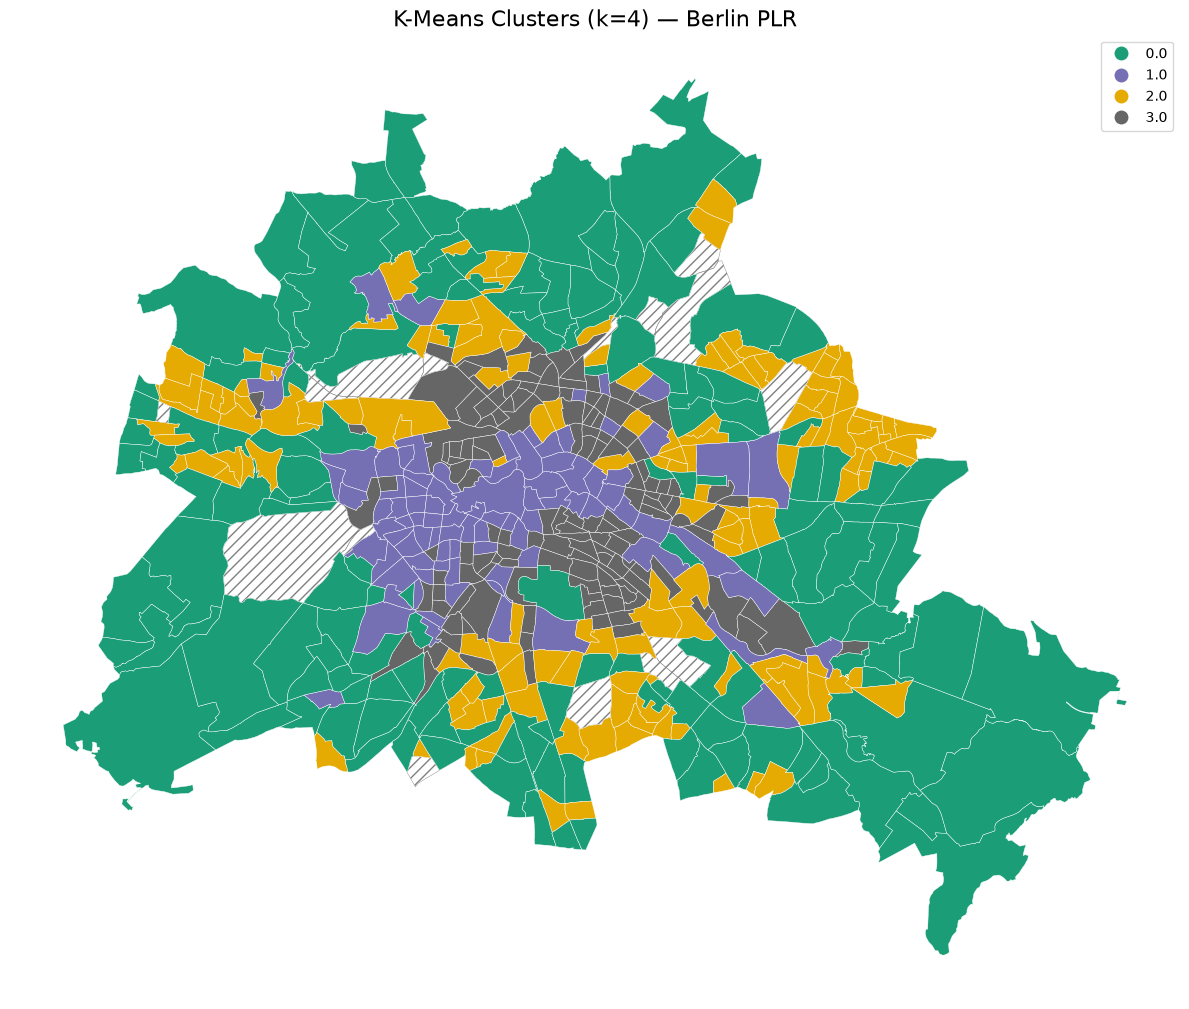

In [55]:
fig, ax = plt.subplots(figsize=(12, 12))

k = 4
# mark missing PLR's
gdf[gdf["cluster_4k"].isna()].plot(
    ax=ax, color="none", edgecolor="grey", hatch="///", linewidth=0.3, label="no data")

# Add clusters
gdf[gdf["cluster_4k"].notna()].plot(
    column="cluster_4k", categorical=True, legend=True,
    cmap="Dark2", edgecolor="white", linewidth=0.3, ax=ax)

# rename legend labels: 0 -> "Cluster 1", 1 -> "Cluster 2", ...
#legend = ax.get_legend()
#for i, text in enumerate(legend.get_texts()):
    #text.set_text(f"Cluster {i + 1}")

ax.set_title(f"K-Means Clusters (k={k}) — Berlin PLR", fontsize=16)
ax.axis("off"); plt.tight_layout(); plt.show()

In order to determine whether the clusters can actually be described as gentrification phases/profiles, we need to take a look at what separates them and what characterizes each cluster. 

In [53]:
profile = df.groupby("cluster_4k")[feat_cols].mean().T
# nach Dimension sortiert für Lesbarkeit
profile = profile.reindex([c for c in feat_cols if c.startswith("re_")]
                          + [c for c in feat_cols if c.startswith("soc_")]
                          + [c for c in feat_cols if c.startswith("com_")])
print(profile.round(2).to_string())

cluster_4k                                                         0        1       2        3
re_miete_niveau                                                14.00    20.23   10.76    16.43
re_miete_trend                                                  0.96     1.64    0.67     1.33
re_leerstandsquote                                              2.21     2.33    1.80     2.03
re_brw_niveau                                                 772.06  3309.71  678.28  2436.18
re_brw_trend                                                   -0.03    -0.30   -0.24    -0.37
re_dichte_all                                                   3.21    13.05    1.12    12.13
re_altbau_share                                                 0.09     0.32    0.05     0.50
re_neubau_share                                                 0.16     0.13    0.04     0.05
soc_young_to_middle_adult_share_2025                            0.30     0.43    0.38     0.47
soc_young_to_middle_adult_share_change_2021_2025  

In [54]:
def is_dynamic(c):
    return any(t in c for t in ["_trend", "_slope", "_change"])

for label, cols in [("LEVEL", [c for c in feat_cols if not is_dynamic(c)]),
                    ("DYNAMIC", [c for c in feat_cols if is_dynamic(c)])]:
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    print(df.groupby("cluster_4k")[cols].mean().T.round(2).to_string())


LEVEL
cluster_4k                                    0        1       2        3
re_miete_niveau                           14.00    20.23   10.76    16.43
re_leerstandsquote                         2.21     2.33    1.80     2.03
re_brw_niveau                            772.06  3309.71  678.28  2436.18
re_dichte_all                              3.21    13.05    1.12    12.13
soc_young_to_middle_adult_share_2025       0.30     0.43    0.38     0.47
soc_average_household_size_2024            1.96     1.72    1.82     1.67
soc_internal_migration_volume_rate_2025    0.14     0.19    0.14     0.17
soc_internal_net_migration_rate_2025       0.01     0.00    0.01    -0.01
soc_transfer_benefit_share_2024            0.06     0.08    0.14     0.12
soc_single_parent_household_share_2024     0.05     0.04    0.06     0.04
com_median_age_level_2026                  7.79     6.96    5.02     5.84
com_share_solo_level_2026                  0.68     0.59    0.80     0.74
com_share_10plus_level_2026    

In [72]:
# for each cluster: look at brw, rent, average_household_size, transfer benefit share, median_age of businesses and upscale share
for c in sorted(df["cluster_4k"].dropna().unique()):
    sub = df[df["cluster_4k"] == c]
    print(f"\nCluster {int(c)} (n={len(sub)}):")
    print(f"  brw          = {sub['re_brw_niveau'].mean():.0f}")
    print(f"  rent         = {sub['re_miete_niveau'].mean():.1f}")
    print(f"  hh_size      = {sub['soc_average_household_size_2024'].mean():.2f}")
    print(f"  transfer     = {sub['soc_transfer_benefit_share_2024'].mean():.2f}")
    print(f"  biz_med_age  = {sub['com_median_age_level_2026'].mean():.1f}")
    print(f"  upscale      = {sub['com_upscale_share_level_2026'].mean():.2f}")
    print(f"  Bezirke: {sub['bez'].value_counts().head(3).to_dict()}")


Cluster 0 (n=150):
  brw          = 772
  rent         = 14.0
  hh_size      = 1.96
  transfer     = 0.06
  biz_med_age  = 7.8
  upscale      = 0.56
  Bezirke: {'06 - Steglitz-Zehlendorf': 24, '03 - Pankow': 21, '05 - Spandau': 19}

Cluster 1 (n=90):
  brw          = 3310
  rent         = 20.2
  hh_size      = 1.72
  transfer     = 0.08
  biz_med_age  = 7.0
  upscale      = 0.62
  Bezirke: {'04 - Charlottenburg-Wilmersdorf': 36, '01 - Mitte': 19, '07 - Tempelhof-Schöneberg': 8}

Cluster 2 (n=145):
  brw          = 678
  rent         = 10.8
  hh_size      = 1.82
  transfer     = 0.14
  biz_med_age  = 5.0
  upscale      = 0.45
  Bezirke: {'10 - Marzahn-Hellersdorf': 27, '11 - Lichtenberg': 23, '05 - Spandau': 21}

Cluster 3 (n=142):
  brw          = 2436
  rent         = 16.4
  hh_size      = 1.67
  transfer     = 0.12
  biz_med_age  = 5.8
  upscale      = 0.48
  Bezirke: {'02 - Friedrichshain-Kreuzberg': 27, '01 - Mitte': 26, '03 - Pankow': 24}


In [73]:
vars_show = ["re_brw_niveau", "re_miete_niveau", "soc_average_household_size_2024",
             "soc_transfer_benefit_share_2024", "com_median_age_level_2026",
             "com_upscale_share_level_2026"]
tbl = df.groupby("cluster_4k")[vars_show].mean().T.round(2)
print(tbl.to_string())

cluster_4k                            0        1       2        3
re_brw_niveau                    772.06  3309.71  678.28  2436.18
re_miete_niveau                   14.00    20.23   10.76    16.43
soc_average_household_size_2024    1.96     1.72    1.82     1.67
soc_transfer_benefit_share_2024    0.06     0.08    0.14     0.12
com_median_age_level_2026          7.79     6.96    5.02     5.84
com_upscale_share_level_2026       0.56     0.62    0.45     0.48


Based on this first exploration, it looks like there is a meaningful structure to the clusters: 
- Cluster 1 — Established inner city. The most expensive and upscale areas (BRW 3310, rent 20.2, upscale share 0.62), with older, settled businesses and very low benefit dependency. Charlottenburg-Wilmersdorf, Mitte. The mature, high-value core.
- Cluster 3 — Dense transition kieze. Also central and dense but cheaper (BRW 2436, rent 16.4), with a younger business stock, more pre-war buildings, and higher benefit shares. Friedrichshain-Kreuzberg, Mitte, Pankow. The actively upgrading inner-city milieu.
- Cluster 0 — Affluent family ring. Mid-level property values but the largest households (1.96) and oldest, most stable businesses, with the lowest benefit share (0.06). Steglitz-Zehlendorf, Pankow, Spandau. Settled, lower-density wealth — not a gentrifying type.
- Cluster 2 — Strained periphery. The cheapest and least upscale areas (BRW 678, rent 10.8) with the highest benefit dependency (0.14). Marzahn-Hellersdorf, Lichtenberg, Spandau. Large peripheral housing estates.

Together these form a gentrification gradient by state — from the advanced core (1) through the active transition zone (3) to two non-gentrifying outer types: stable affluence (0) and social strain (2) — rather than a sequence of temporal phases.

## Most distinguishing variables:

In [76]:
Xs = X_scaled.copy()
Xs["cluster_4k"] = df["cluster_4k"].values

# auf standardisierten Daten, damit die Variablen vergleichbar sind
means_by_cluster = Xs.groupby("cluster_4k")[feat_cols].apply(
    lambda g: g.mean())   # falls df roh ist, nimm X_scaled mit cluster-Spalte
# besser: standardisiert
Xs = X_scaled.copy(); Xs["cluster_4k"] = df["cluster_4k"].values
spread = Xs.groupby("cluster_4k")[feat_cols].mean().var().sort_values(ascending=False)
print(spread.head(20))

re_brw_niveau                                  0.857296
re_miete_niveau                                0.805934
re_altbau_share                                0.805855
re_dichte_all                                  0.805692
soc_young_to_middle_adult_share_2025           0.671929
com_share_solo_level_2026                      0.652160
re_brw_trend                                   0.607197
com_n_gastro                                   0.550424
soc_single_parent_household_share_2024         0.541097
com_exit_rate_level_2026                       0.515219
com_median_age_level_2026                      0.504414
soc_average_household_size_2024                0.479698
soc_transfer_benefit_share_2024                0.454840
com_entry_rate_level_2026                      0.375490
com_tourism_share_level_2026                   0.338258
soc_internal_migration_volume_rate_2025        0.329522
soc_transfer_benefit_share_change_2020_2024    0.326458
re_miete_trend                                 0

## Add-on: Clusters based on change variables only

In [ ]:
id_cols = ["plr_id", "plr_name", "bez"]
non_features = id_cols + ["cluster_3k", "cluster_4k", "ms_portion", "ms_binary", "plr_id_str"]
feat_cols = [c for c in df.columns if c not in non_features]
print(len(feat_cols), "Features") 

X = df[feat_cols]

X_scaled = pd.DataFrame(
    PowerTransformer("yeo-johnson", standardize=True).fit_transform(X),
    columns=feat_cols, index=X_imp.index,
)

X_scaled.head(3)

,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_change_2021_2024,soc_average_household_size_2024,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,1.707607,1.345248,1.062483,1.401119,-0.514159,0.938569,0.789265,-0.423212,-0.854709,-1.183481,...,-0.059062,-0.227172,1.531979,0.952109,0.959637,-1.143363,-0.728138,-0.314274,-0.225292,0.638800
1,1.219387,0.033646,1.781115,1.306092,-1.096115,1.599031,0.985896,-0.282827,-1.223596,-0.004727,...,0.407217,0.680906,1.898433,0.860206,1.724478,-0.424651,-1.854356,1.880504,0.381165,1.777773
2,1.767611,0.419433,0.074113,1.329091,-1.175228,1.284139,0.736851,0.555171,-0.191582,-0.444817,...,-0.021163,0.706418,2.197820,-0.451547,-0.201956,-0.461120,-1.439860,0.830252,0.755869,0.929094


21 change-Variablen


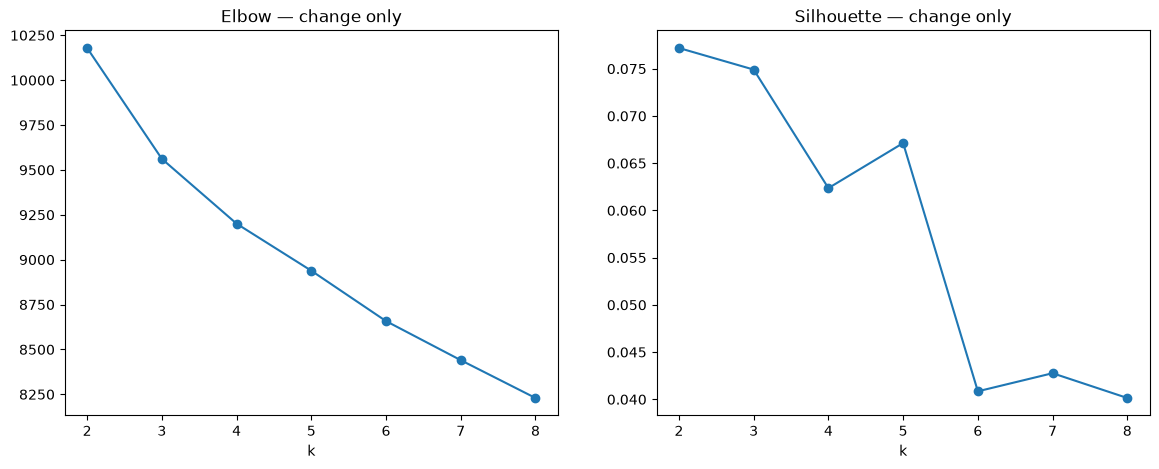

k=2: silhouette = 0.077
k=3: silhouette = 0.075
k=4: silhouette = 0.062
k=5: silhouette = 0.067
k=6: silhouette = 0.041
k=7: silhouette = 0.043
k=8: silhouette = 0.040


In [69]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

change_cols = [c for c in feat_cols if any(t in c for t in ["_trend","_slope","_change"])]
X_change = X_scaled[change_cols]     # schon standardisiert (Option A)
print(f"{len(change_cols)} change-Variablen")

# Elbow + Silhouette über k
Ks = range(2, 9)
wcss, sils = [], []
for k in Ks:
    km = KMeans(k, n_init=10, random_state=0).fit(X_change)
    wcss.append(km.inertia_)
    sils.append(silhouette_score(X_change, km.labels_))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14,5))
a1.plot(Ks, wcss, "o-"); a1.set_title("Elbow — change only"); a1.set_xlabel("k")
a2.plot(Ks, sils, "o-"); a2.set_title("Silhouette — change only"); a2.set_xlabel("k")
plt.show()

for k, s in zip(Ks, sils):
    print(f"k={k}: silhouette = {s:.3f}")